In [1]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp
from dynrdpg.datasets import simulate_network_bspline

0.19481142857142858


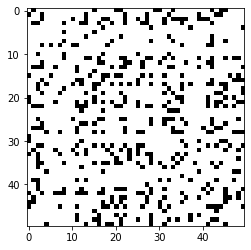

In [2]:
k_steps = 5

Y, X, probas_true = simulate_network_gp(
    n_nodes=50, n_time_steps=100 + k_steps, 
    density=0.2, random_state=32, length_scale=3)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

0.09967545454545454


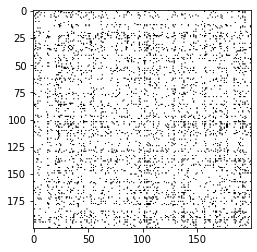

In [21]:
k_steps = 5

Y, X, probas_true = simulate_network_bspline(
    n_nodes=200, n_time_steps=50, k_steps=k_steps,
    density=0.1, random_state=32, df=5)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [35]:
import os

out_dir = f'fase_data/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

np.savetxt(os.path.join(out_dir, 'time_points.npy'), np.linspace(0, 1, len(Y)))
for t in range(len(Y)):
    np.savetxt(os.path.join(out_dir, f'Y_{t+1}.npy'), Y[t].toarray())
    np.savetxt(os.path.join(out_dir, f'X_{t+1}.npy'), X[t])

In [36]:
! Rscript fase.R

Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var


── Column specification ────────────────────────────────────────────────────────
cols(
  X1 = col_double()
)

[1] "q = 4 ngcv = -0.950033197028694"
[1] "q = 6 ngcv = -0.949999557021181"
[1] "q = 8 ngcv = -0.949648289825792"
[1] "q = 10 ngcv = -0.949344187337935"
     fase_mse fase_kstep_0 fase_kstep_1 fase_kstep_2 fase_kstep_3 fase_kstep_4
1 0.001099808   0.00052239 0.0005505384 0.0006450121 0.0008061534  0.001034518
  fase_kstep_5
1  0.001330875


In [31]:
k_steps = 5

rdpg = DynamicRDPG(n_features=2, rw_order=2)
rdpg.sample(Y[:-k_steps], n_burnin=500, n_samples=500)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:31<00:00,  3.02it/s]


In [32]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
#print(rdpg.auc_)
np.mean((X_pred - X[:-k_steps]) ** 2)

0.001516562350727815

In [33]:
rdpg.probas_.shape

(50, 19900)

In [41]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True)#.mean(axis=0)


#print(np.mean((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1])**2))
#for k in range(k_steps):
#    y_predk = y_pred[k][subdiag]
#    print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))

In [35]:
cis = np.quantile(y_pred[:, -5], q=[0.025, 0.975], axis=0)

In [36]:
np.abs(cis[0] - cis[1]).mean()

0.11635123721962802

In [37]:
cis[:, 0]

array([0.01155419, 0.0819562 ])

In [38]:
np.logical_and(probas_true[-5][subdiag] <= cis[1], 
               probas_true[-5][subdiag] >= cis[0]).mean() 

0.9584422110552764

In [81]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score

In [86]:
y_hat = y_pred.mean(axis=0)[0] 
y_true = Y[-5].toarray()[subdiag]
print(np.mean((y_hat - y_true) ** 2))
print(roc_auc_score(y_true, y_hat))
print(classification_report(y_true, y_hat > 0.5))

0.07646244114387717
0.7705475343350116
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     18029
         1.0       0.51      0.04      0.08      1871

    accuracy                           0.91     19900
   macro avg       0.71      0.52      0.51     19900
weighted avg       0.87      0.91      0.87     19900



In [30]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True).mean(axis=0)


print(np.mean((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1])**2))
for k in range(k_steps):
    y_predk = y_pred[k]
    print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))

0.0005149530178449647
0.0007061158277149554
0.0009653195136848191
0.0012865939591996437
0.0016789805959663378
0.0021545563621582484


In [39]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True).mean(axis=0)


print(np.mean((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1])**2))
for k in range(k_steps):
    y_predk = y_pred[k]
    print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))

0.0007881480580480153
0.0009336969570159773
0.0011541113239596933
0.00144255353559964
0.0018059280031288965
0.002256835287565892
